## Grid explorer

In this notebook you will see how to:

- inspect the grid properties of GRIB data
- access the latitudes/longitudes of a field
- plot the gridpoints of a field
- interpolate GRIB data from one grid to another (regridding)
- extract the nearest gridpoint from a field

### Components of earthkit

This tutorial uses the following earthkit components - click any logo to open the package documentation:

<div align="center">
  <br>
  <a href="https://earthkit-data.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-data-light.svg" alt="earthkit-data" width="200">
  </a>
  <a href="https://earthkit-plots.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-plots-light.svg" alt="earthkit-plots" width="200">
  </a> 
  <a href="https://earthkit-geo.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-geo-light.svg" alt="earthkit-geo" width="200">
  </a>
</div>

### 1. Getting the data

The input data is a GRIB file containing 1000 hPa temperature fields on 3 different global grids. 

First, fetch the file and list its contents.

In [1]:
import earthkit.data as ekd

ds = ekd.from_source("sample", "grids_3.grib").to_fieldlist()
ds.ls()

grids_3.grib:   0%|          | 0.00/33.0k [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2015-04-22 12:00:00,2015-04-22 12:00:00,0 days,1000,pressure,None,regular_ll
1,t,2015-04-22 12:00:00,2015-04-22 12:00:00,0 days,1000,pressure,None,reduced_gg
2,t,2015-04-22 12:00:00,2015-04-22 12:00:00,0 days,1000,pressure,None,healpix


Next, select the field you will inspect in the rest of the notebook.

To try another grid type change the `gridType` in the `sel()` call below and rerun the notebook.

In [2]:
# choose one from: regular_ll, reduced_gg, healpix
f = ds.sel({"geography.grid_type": "regular_ll"})[0]
f.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2015-04-22 12:00:00,2015-04-22 12:00:00,0 days,1000,pressure,None,regular_ll


### 2. Inspecting the grid

With `.get()` you can inspect the relevant metadata.

In [3]:
f.get("parameter.variable"), f.get("geography.grid_type")

('t', 'regular_ll')

The field's shape is related to the geography. For grids with  regular 2D structure, like regular latitude-longitude grids, the geography's shape is always 2D. Otherwise, like for reduced Gaussian grids, it is 1D.

In [4]:
f.geography.shape()

(37, 72)

When you access the latitudes and longitudes via `.geography.latlons()` you get numpy arrays with the field's shape.

In [5]:
lat, lon = f.geography.latlons()
lat.shape, lon.shape

((37, 72), (37, 72))

You can access the field values either with `to_numpy()` or via the `values` property. By default, `to_numpy()` respects the field's shape unless you use the `flatten=True` option.

In [6]:
f.to_numpy().shape, f.to_numpy(flatten=True).shape

((37, 72), (2664,))

When using the `values` property always a 1D array is returned.

In [7]:
f.values.shape

(2664,)

### 3. Plotting the gridpoints

This example shows you how to plot the original gridpoint positions of the field.

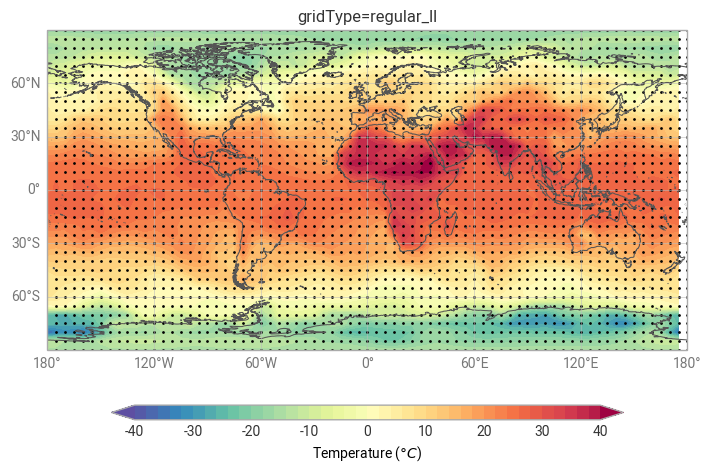

In [8]:
import earthkit.plots as ekp

chart = ekp.Map(size=(7, 7))
chart.contourf(f, units="celsius", auto_style=True)

# plot the original grid points
chart.grid_points(f, c="black")  # marker="+"

chart.title(f"gridType={f.get('geography.grid_type')}")
chart.coastlines()
chart.gridlines()
chart.legend()

chart.show()

The next plot shows a smaller area and displays the grid values at each grid point.

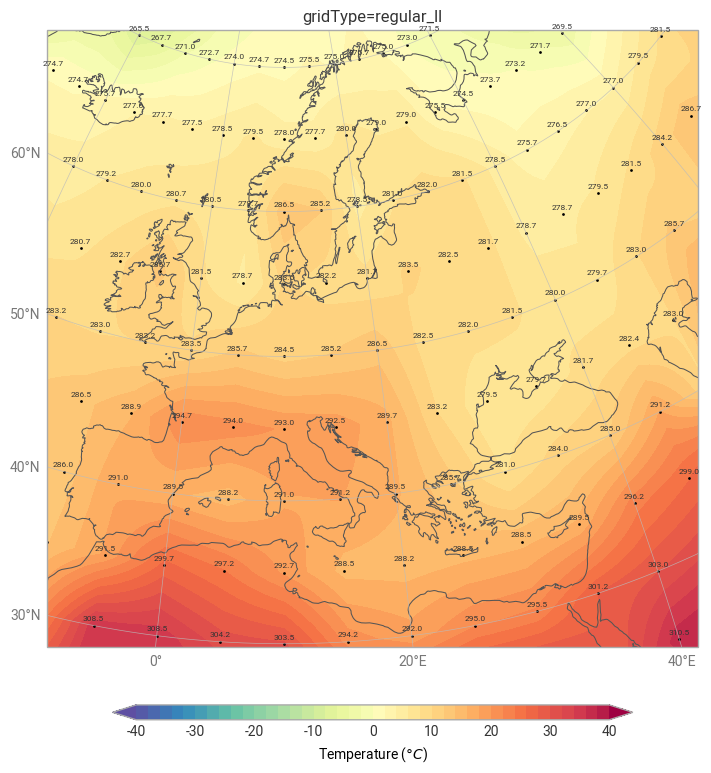

In [9]:
import cartopy.crs as ccrs

chart = ekp.Map(domain="Europe")
chart.contourf(f, units="celsius", auto_style=True)
# plot the original grid points
chart.grid_points(f, c="black")  # marker="+"

# generate grid values
lat, lon, vals = f.data(flatten=True)
labels = [f"{x:.1f}" for x in vals]
for i, lbs in enumerate(labels):
    chart.ax.annotate(
        lbs,
        (lon[i], lat[i]),
        transform=ccrs.Geodetic(),
        xytext=(0, 5),
        textcoords="offset pixels",
        annotation_clip=True,
        fontsize=6,
        horizontalalignment="center",
    )

chart.title(f"gridType={f.metadata('gridType')}")
chart.coastlines()
chart.gridlines()
chart.legend()

chart.show()

### 4. Regridding

You can regrid data with `earthkit.geo.regrid.regrid()`.

In [10]:
import earthkit.geo as ekg

# the target grid is a global 10x10 degree regular latitude-longitude grid
grid = {"grid": [10, 10]}

# perform interpolation for the field f
print(f)
ds_res = ekg.regrid(f, grid=grid, interpolation="linear")

Field(t, 2015-04-22 12:00:00, 2015-04-22 12:00:00, 0:00:00, 1000, pressure, None, regular_ll)


The next cell plots the original and interpolated fields over a subarea.

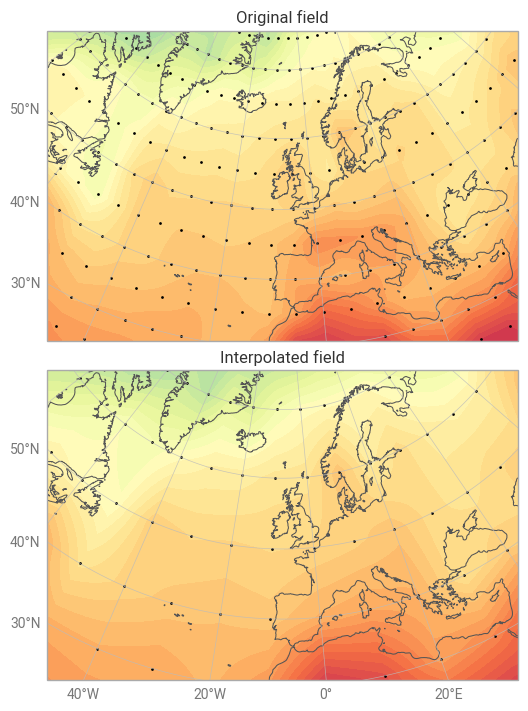

In [11]:
figure = ekp.Figure(domain="North Atlantic", rows=2, columns=1)

# the original field
subplot = figure.add_map(0, 0)
subplot.contourf(f, units="celsius", auto_style=True)
subplot.grid_points(f, c="black")
subplot.title("Original field")

# the interpolated field
subplot = figure.add_map(1, 0)
subplot.contourf(ds_res, units="celsius", auto_style=True)
subplot.grid_points(ds_res, c="black")
subplot.title("Interpolated field")

figure.coastlines()
figure.gridlines()

figure.show()

### 5. Getting the nearest gridpoint

In this example you can see how to extract the nearest gridpoint value of a field using [earthkit.geo.distance.nearest_point_haversine()](https://earthkit-geo.readthedocs.io/en/latest/autoapi/earthkit/geo/distance/nearest_point_haversine.html#earthkit.geo.distance.nearest_point_haversine).

In [12]:
# ref location (lat, lon)
p_ref = (51.45, -0.97)

# get latlon
lat, lon = f.geography.latlons()

# get nearest point index
idx, dist = ekg.distance.nearest_point_haversine(p_ref, (lat, lon))
idx

array([576])

In [13]:
# extract field value at given index
f.values[idx]

array([283.45458984])